In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/my_project.zip'  # note the exact spelling and case
extract_path = '/content/my_project'

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [ ]:
train_dir = "/content/my_project/my_project/train"
val_dir = "/content/my_project/my_project/val"
test_dir = "/content/my_project/my_project/test"


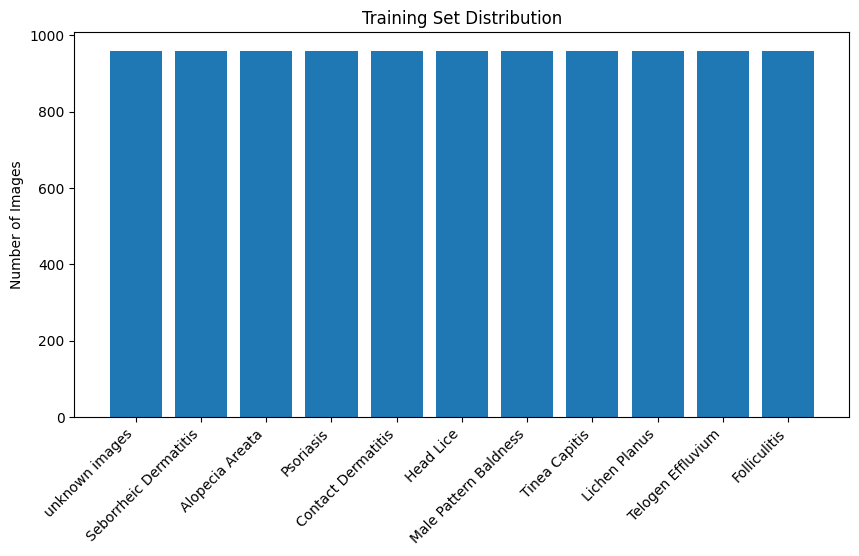

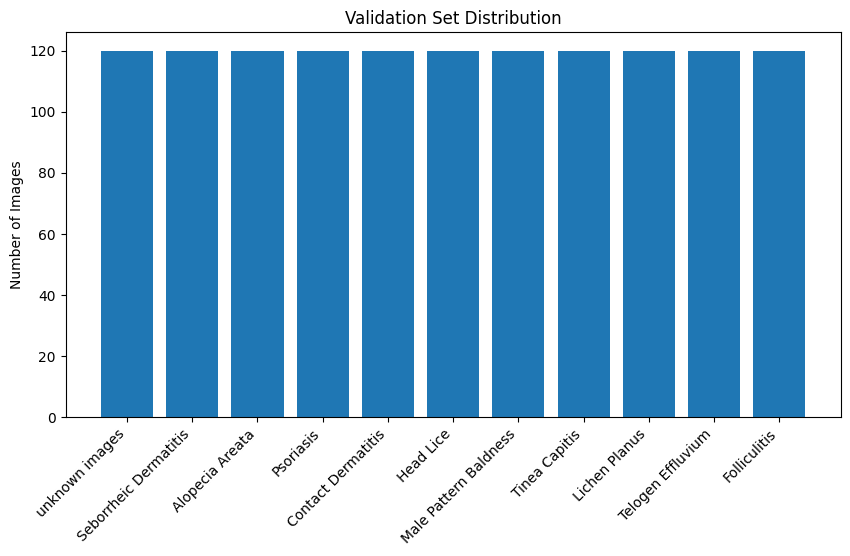

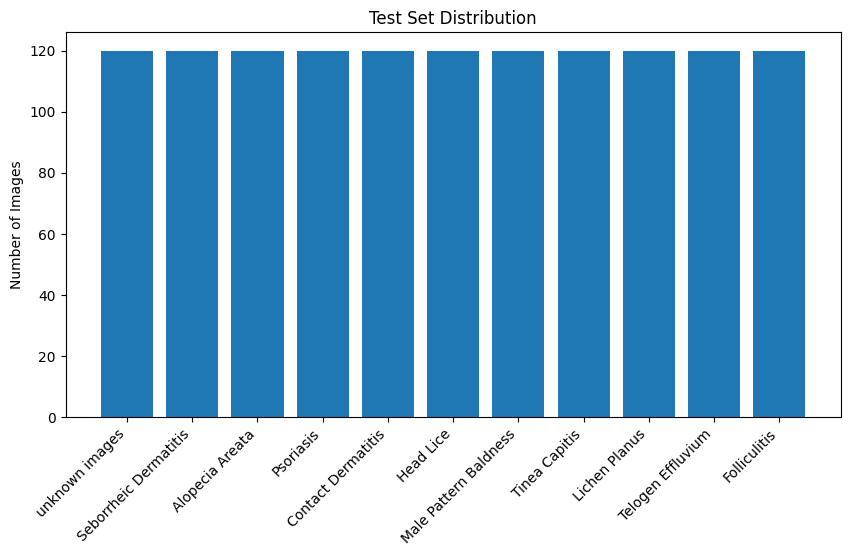

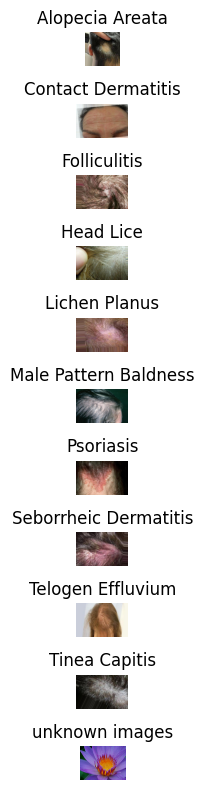

In [ ]:
import matplotlib.pyplot as plt
import os
import random

# ---- 1. Class Distribution ----
def plot_class_distribution(directory, title):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))

    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(train_dir, "Training Set Distribution")
plot_class_distribution(val_dir, "Validation Set Distribution")
plot_class_distribution(test_dir, "Test Set Distribution")


# ---- 2. Show Sample Images ----
def show_sample_images(directory, num_images=5):
    class_names = sorted(os.listdir(directory))
    plt.figure(figsize=(15, 8))

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue
        # Pick random image
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = plt.imread(img_path)
        plt.subplot(len(class_names), num_images, i * num_images + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)

    plt.tight_layout()
    plt.show()

# Show 1 sample from each class in training set
show_sample_images(train_dir, num_images=1)


Found 10560 files belonging to 11 classes.
Found 1320 files belonging to 11 classes.
Found 1320 files belonging to 11 classes.
Epoch 1/30
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.2744 - loss: 2.1749
Epoch 1: val_loss improved from inf to 1.34771, saving model to /content/drive/MyDrive/my_project_models/hair_disease_best_model.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 150s 429ms/step - accuracy: 0.2747 - loss: 2.1736 - val_accuracy: 0.5409 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 2/30
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5897 - loss: 1.1664
Epoch 2: val_loss improved from 1.34771 to 0.74966, saving model to /content/drive/MyDrive/my_project_models/hair_disease_best_model.keras
330/330 ━━━━━━━━━━━━━━━━━━━━ 74s 62ms/step - accuracy: 0.5898 - loss: 1.1661 - val_accuracy: 0.7424 - val_loss: 0.7497 - learning_rate: 0.0010
Epoch 3/30
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7257 - loss: 0.7755
Epoch 3: val_loss improved from 0.74966 to 0.4552

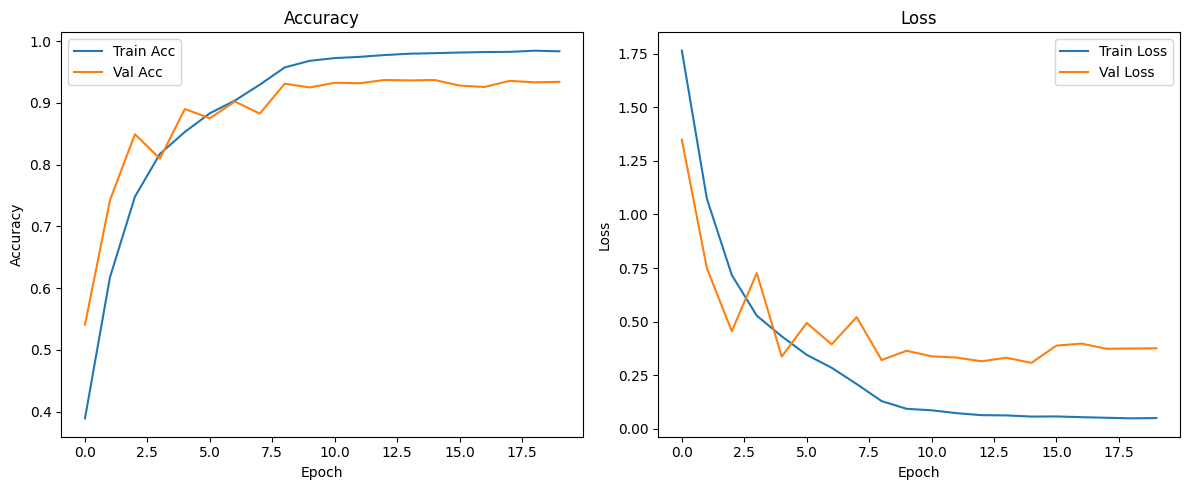

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
import random

# Fix seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 11  # 10 diseases + 1 unknown
EPOCHS = 30

# Load datasets with one-hot labels
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Data augmentation layer (applied only during training)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Normalize pixel values to [0,1]
normalization_layer = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

# Build CNN model
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for saving best model, early stopping, and LR reduction
checkpoint_path = "/content/drive/MyDrive/my_project_models/hair_disease_best_model.keras"

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

# Load best saved model
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)

# Find best epoch index (lowest val_loss)
best_epoch = np.argmin(history.history['val_loss'])

# Get train and val accuracy at best epoch
best_train_acc = history.history['accuracy'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

print("\n=== Accuracy Summary ===")
print(f"Best Epoch: {best_epoch + 1}")
print(f"Training Accuracy at Best Epoch:   {best_train_acc:.4f}")
print(f"Validation Accuracy at Best Epoch: {best_val_acc:.4f}")
print(f"Test Accuracy (best model):        {test_acc:.4f}")

# Plot training and validation accuracy/loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Found 10560 files belonging to 11 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━

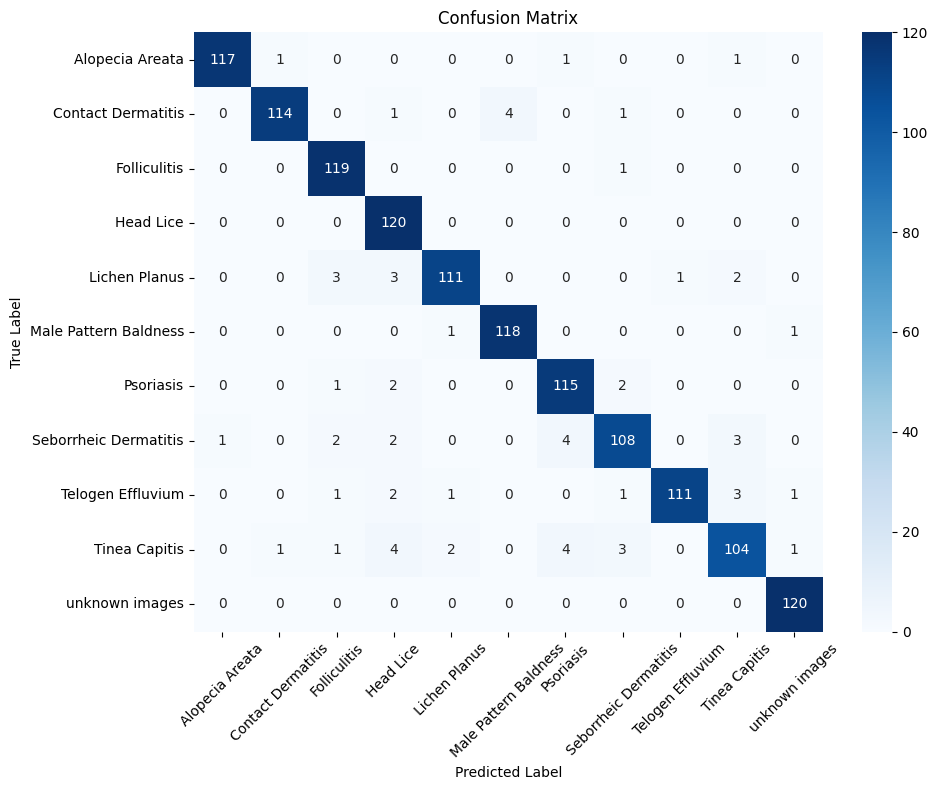

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# STEP 1: Get class names (must be BEFORE you mapped train_ds)
class_names = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
).class_names

# STEP 2: Get predictions and true labels
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# STEP 3: Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# STEP 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
